<a href="https://colab.research.google.com/github/RicardoV1e1r4/Processamento_de_Sinais_I/blob/main/praticas%20/pratica01/Exe6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 6. Calcule a resposta de h_banheiro[n] para uma entrada igual ao sinal de áudio e ao sinal da taça. Note que essa operação equivale ao sinal de áudio e ao sinal da taça se propagando em ambiente modelado pela resposta ao impulso h_banheiro[n].

(c) Comente os resultados obtidos.

Dica: Para convoluir dois sinais, eles precisam estar na mesma frequência de amostragem

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from IPython.display import Audio

### (a) Avalie as respostas no tempo.

In [51]:
fs_hb, hb = wavfile.read('data_h_banheiro.wav')

fs_t, taca = wavfile.read('data_sinal_taca.wav')

fs_a, audio = wavfile.read('data_handel.wav')

In [52]:
# NÃO FUNCIONA

y_audio = np.convolve(audio, hb)
y_taca = np.convolve(taca, hb)

In [53]:
# @title
def zero_pad(x, L):
  l = len(x)
  zeros = np.zeros(L - l)

  x = np.append(x, zeros)
  return x

In [54]:
# @title

l_hb   = len(hb)

# Convolução do áudio do banheiro com o áudio da taça
l_taca = len(taca)

l_conv = l_hb + l_taca - 1
n = np.arange(0, l_conv)

# Convolução do áudio do banheiro com o áudio handel
l_audio = len(audio)

l_conv_audio = l_hb + l_audio - 1
n_audio = np.arange(0, l_conv_audio)


In [55]:
# TAÇA
# FFT do áudio do banheiro para convoluir com o áudio da taça
Y_hb_taca = np.fft.fft(hb, l_conv)

# FFT do áudio da taça
Y_taca = np.fft.fft(taca, l_conv)

G = Y_hb_taca * Y_taca

# HANDEL
# FFT do áudio do banheiro para convoluir com o áudio handel
Y_hb_audio = np.fft.fft(hb, l_conv_audio)

# FFT do áudio handel
Y_audio = np.fft.fft(audio, l_conv_audio)

M = Y_hb_audio * Y_audio

# IFFT dos produtos
g = np.fft.ifft(G)
m = np.fft.ifft(M)

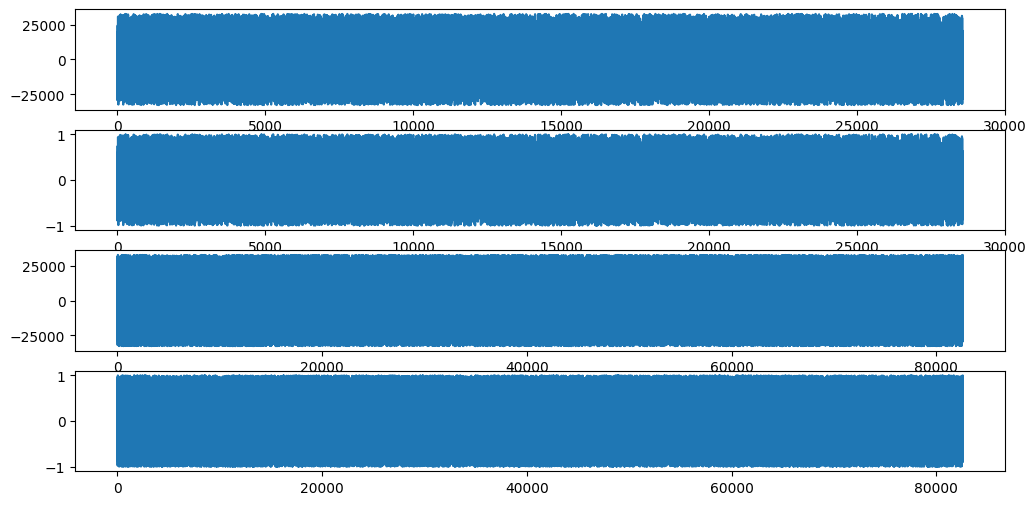

In [56]:
# @title
figure, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 6))

ax1.plot(n, y_taca)

ax2.plot(n, y_taca/(np.max(abs(y_taca))))

ax3.plot(n_audio, y_audio)

ax4.plot(n_audio, y_audio/(np.max(abs(y_audio))))

### (b) Ouça as respostas.

In [57]:
# Audio do banheiro

Audio(hb, rate=(fs_hb))

In [58]:
# Audio da taça

Audio(taca, rate=fs_t)

In [59]:
# Audio convoluido

Audio(np.real(g), rate=fs_t)

In [60]:
# Áudio handel original
Audio(audio, rate=fs_a)

In [61]:
# Áudio handel convoluido com banheiro
Audio(np.real(m), rate=fs_a)